# Quantum Statistical Potential

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/input_files/QSP_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/QSP_Tutorial.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files',  'QSP_cgs.yaml')

/Users/silves28/Documents/Codes/sarkas/sarkas/__init__.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources









     _______.     ___      .______       __  ___      ___           _______.
    /       |    /   \     |   _  \     |  |/  /     /   \         /       |
   |   (----`   /  ^  \    |  |_)  |    |  '  /     /  ^  \       |   (----`
    \   \      /  /_\  \   |      /     |    <     /  /_\  \       \   \    
.----)   |    /  _____  \  |  |\  \----.|  .  \   /  _____  \  .----)   |   
|_______/    /__/     \__\ | _| `._____||__|\__\ /__/     \__\ |_______/    
                                                                            


An open-source pure-python molecular dynamics suite for non-ideal plasmas.




********************************************************************************
                                 Preprocessing                                  
********************************************************************************

Job ID: qsp_cgs
Job directory: SarkasSimulations/qsp_cgs
PreProcessing directory: 
SarkasSimulations/qsp_cgs/PreProcessing

Equil

PP acceleration timer:   0%|          | 0/21 [00:00<?, ?it/s]

Time of PP acceleration calculation averaged over 20 steps:
0 min 0 sec 30 msec 970 usec 641 nsec 



PM acceleration timer:   0%|          | 0/21 [00:00<?, ?it/s]

Time of PM acceleration calculation averaged over 20 steps:
0 min 0 sec 32 msec 896 usec 956 nsec 



...

Time of a single Equilibration step averaged over 20 steps:
0 min 0 sec 70 msec 679 usec 301 nsec 



  0%|          | 0/21 [00:00<?, ?it/s]

Time of a single Production step averaged over 20 steps:
0 min 0 sec 64 msec 411 usec 551 nsec 



----------------------- Total Estimated Times ------------------------ 


Equilibration Time: 1 hrs 57 min 47 sec

Production Time: 7 hrs 9 min 24 sec

Total Run Time: 9 hrs 7 min 12 sec


========================= Filesize Estimates =========================

Equilibration:
	H5MD filesize: 1 GB 542 MB 566 KB 868 bytes

Production:
	H5MD filesize: 10 GB 202 MB 415 KB 88 bytes

Total minimum required space: 11 GB 744 MB 981 KB 956 bytes


Testing PPPM parameter combinations:   0%|          | 0/1092 [00:00<?, ?it/s]


OPTIMAL PPPM CONFIGURATION:
  Target Error: 1.0000e-05
  Mesh: 60 | CAO: 6 | rc: 1.7235e-08
  Ewald alpha: 2.0887e+08 | Force Error: 3.7457e-06
  PP Time: 7.5131e-03 s | PM Time: 2.2664e-02 s
  Total Time: 3.0177e-02 s

Results saved to:
  Full parameter sweep data: SarkasSimulations/qsp_cgs/PreProcessing/TimingStudy_data_qsp_cgs.csv
  Pareto-optimal configurations: SarkasSimulations/qsp_cgs/PreProcessing/Pareto_optimal_PPPM_qsp_cgs.csv
  Visualizations: SarkasSimulations/qsp_cgs/PreProcessing/PPPM_Plots

Figures can be found in SarkasSimulations/qsp_cgs/PreProcessing/PPPM_Plots


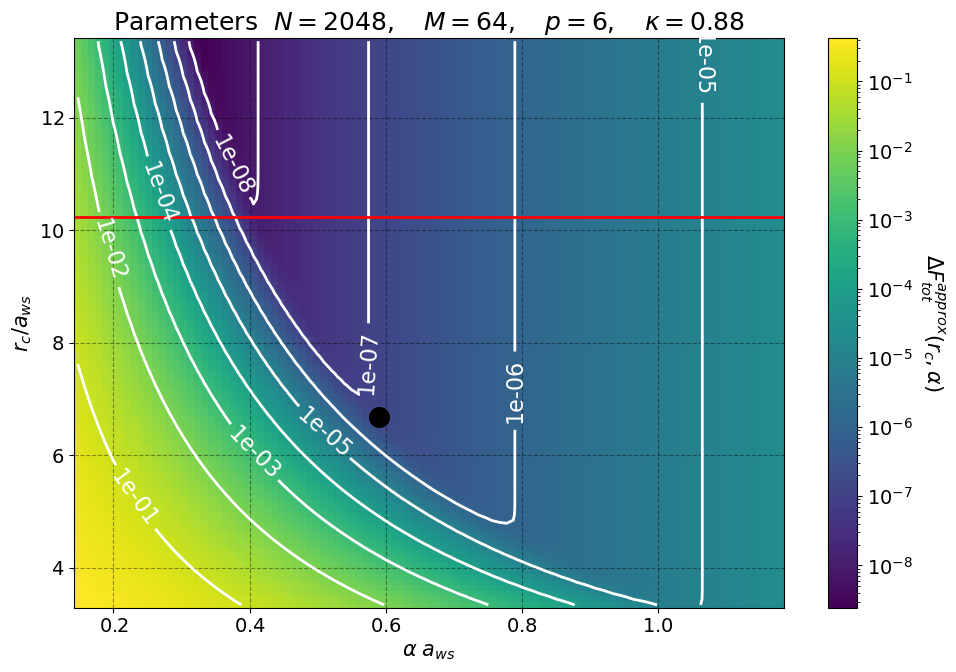

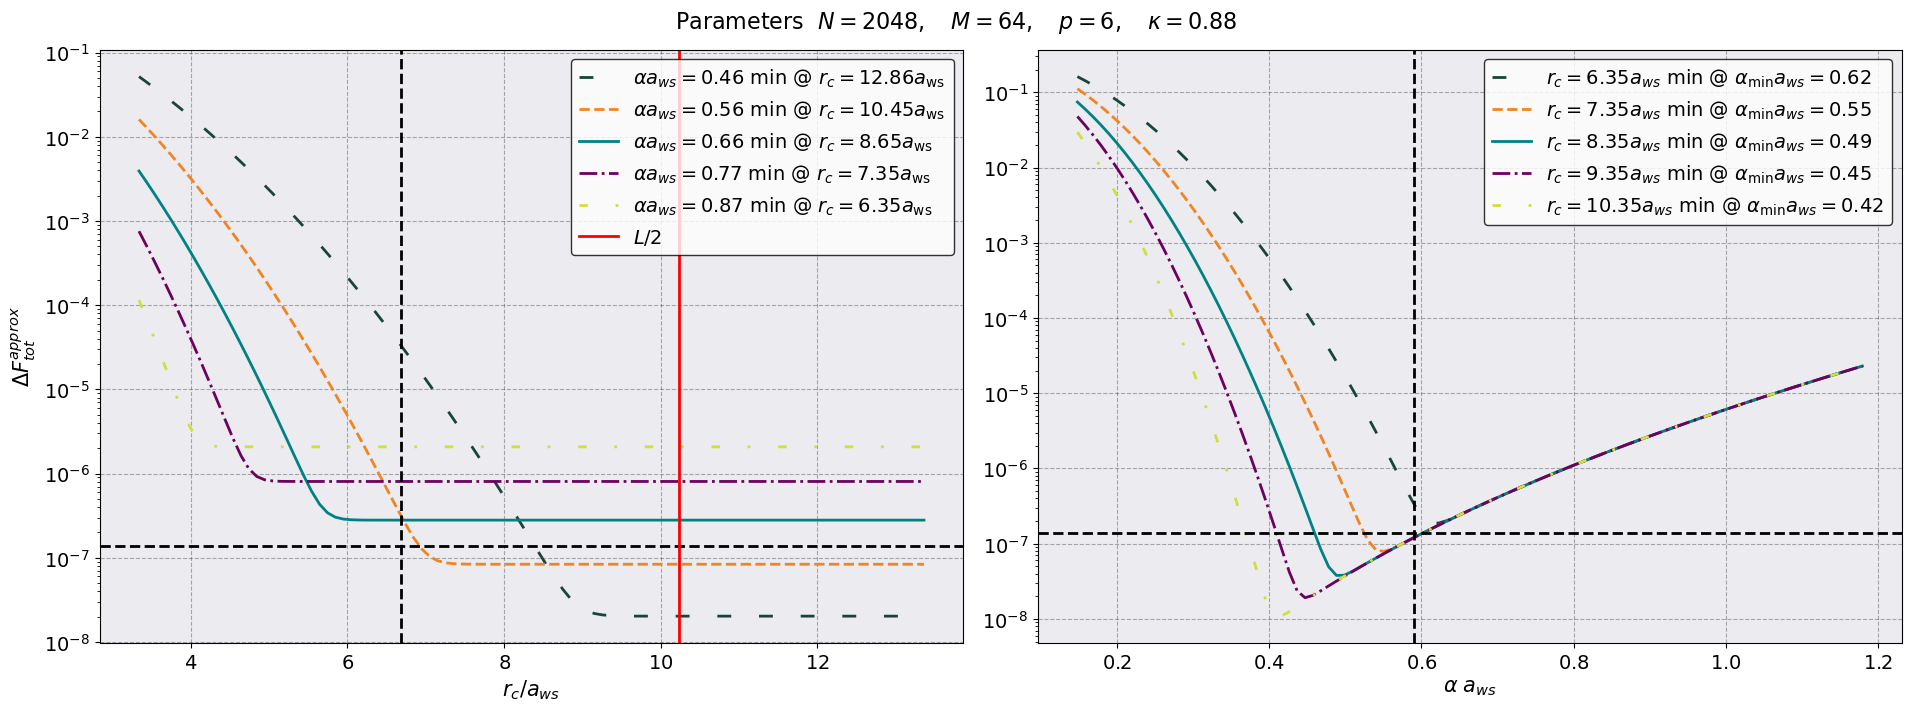

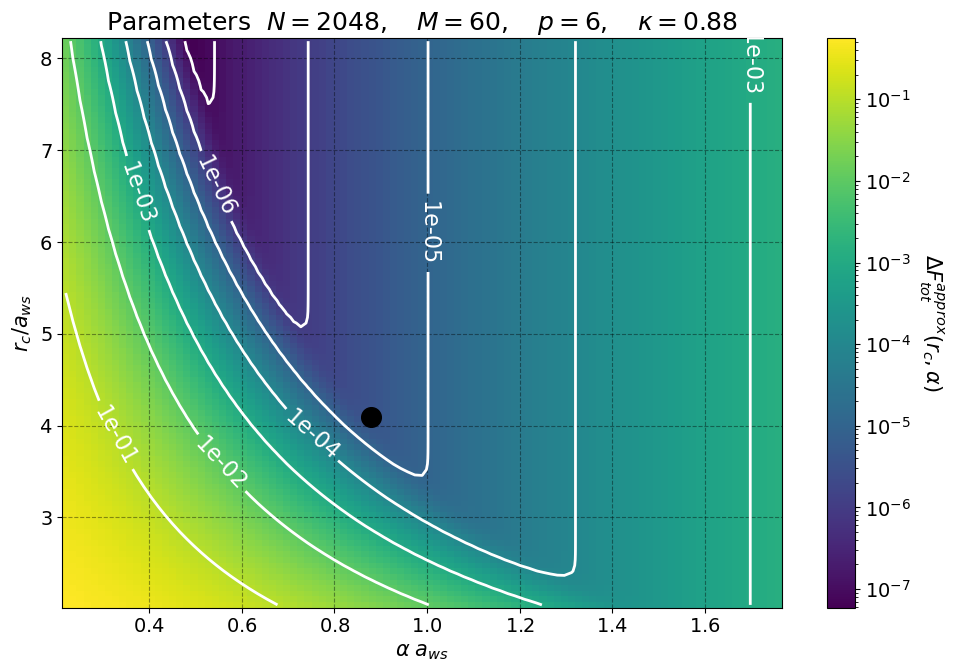

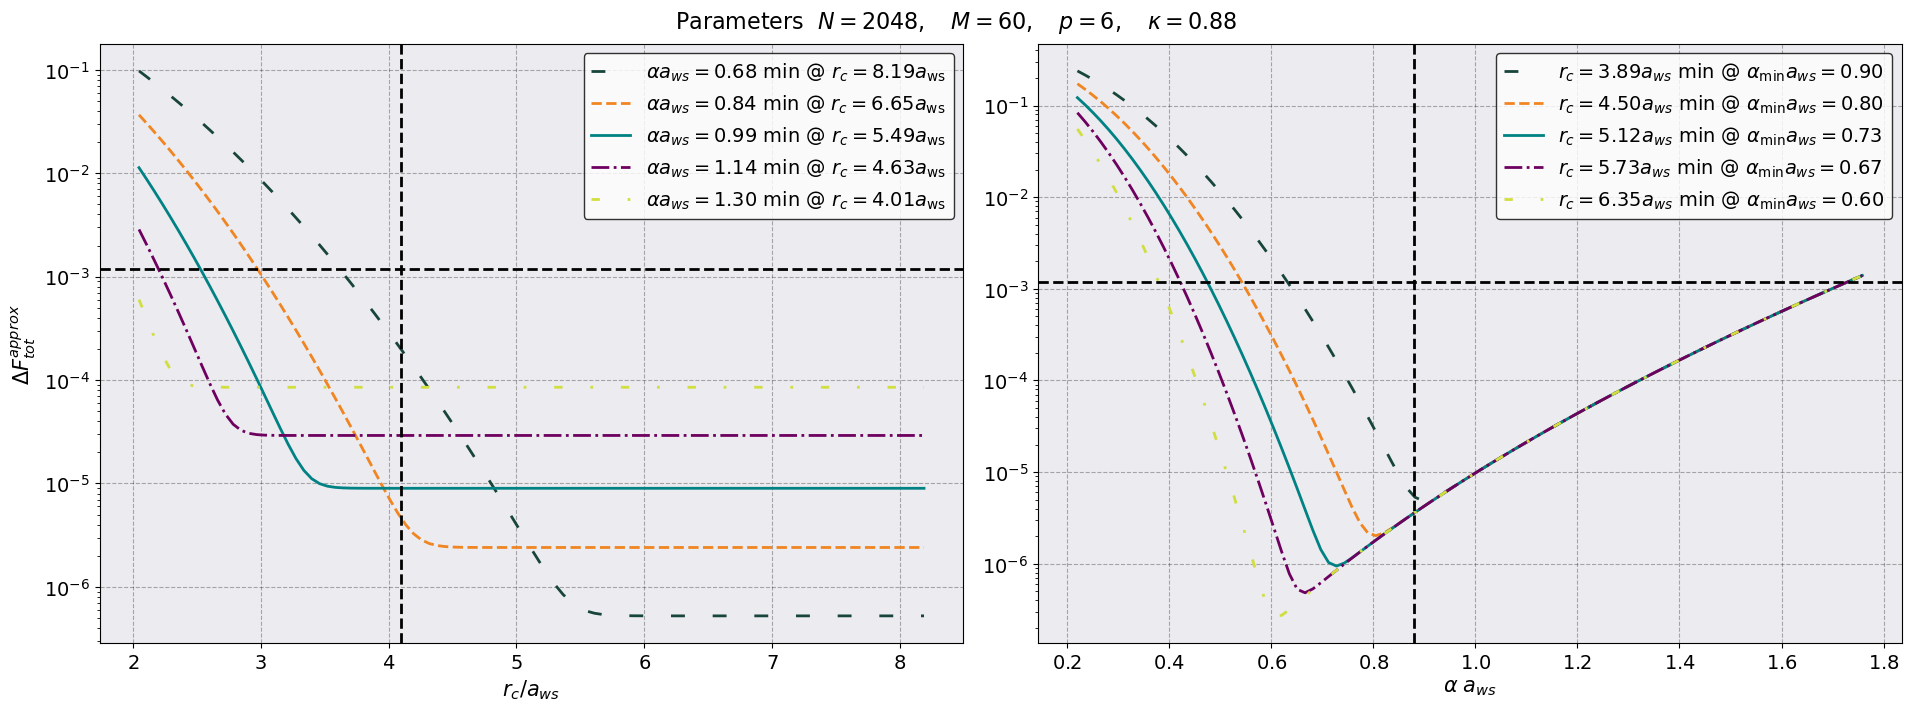

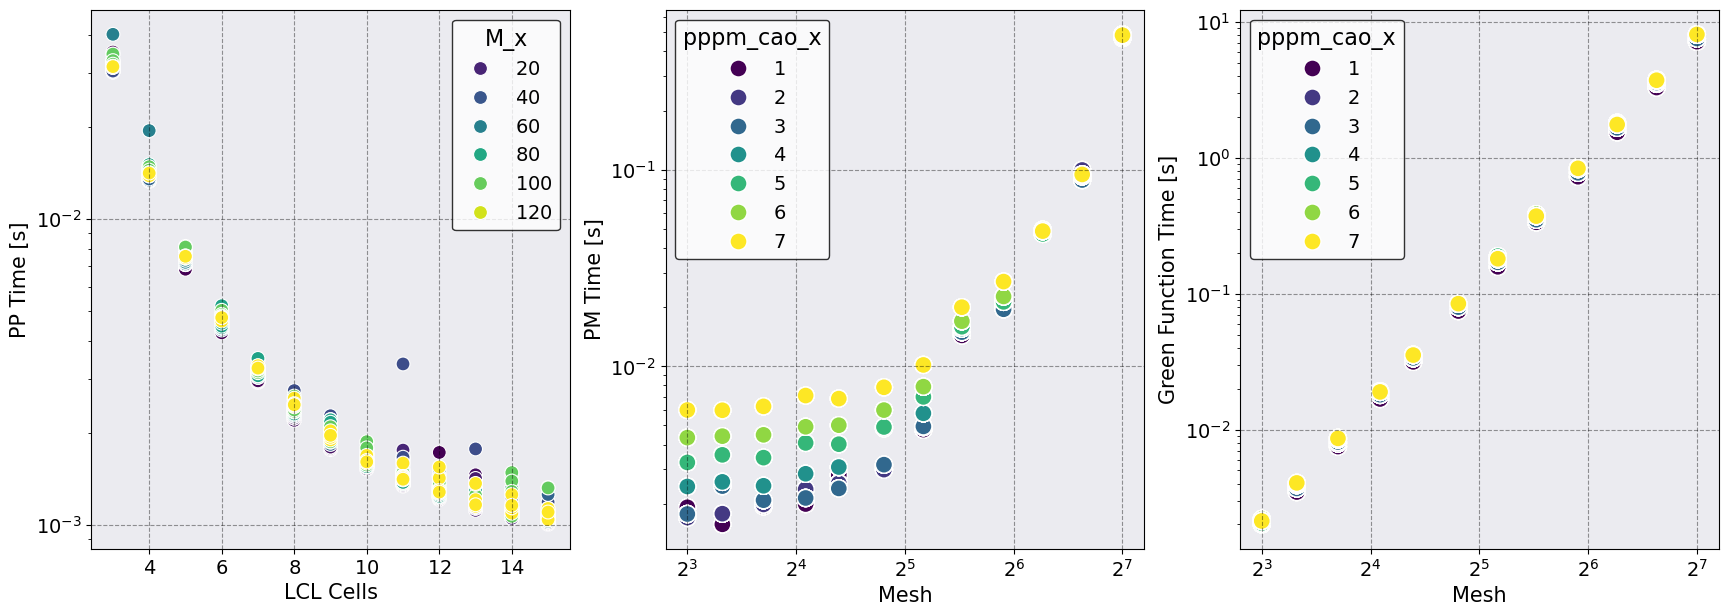

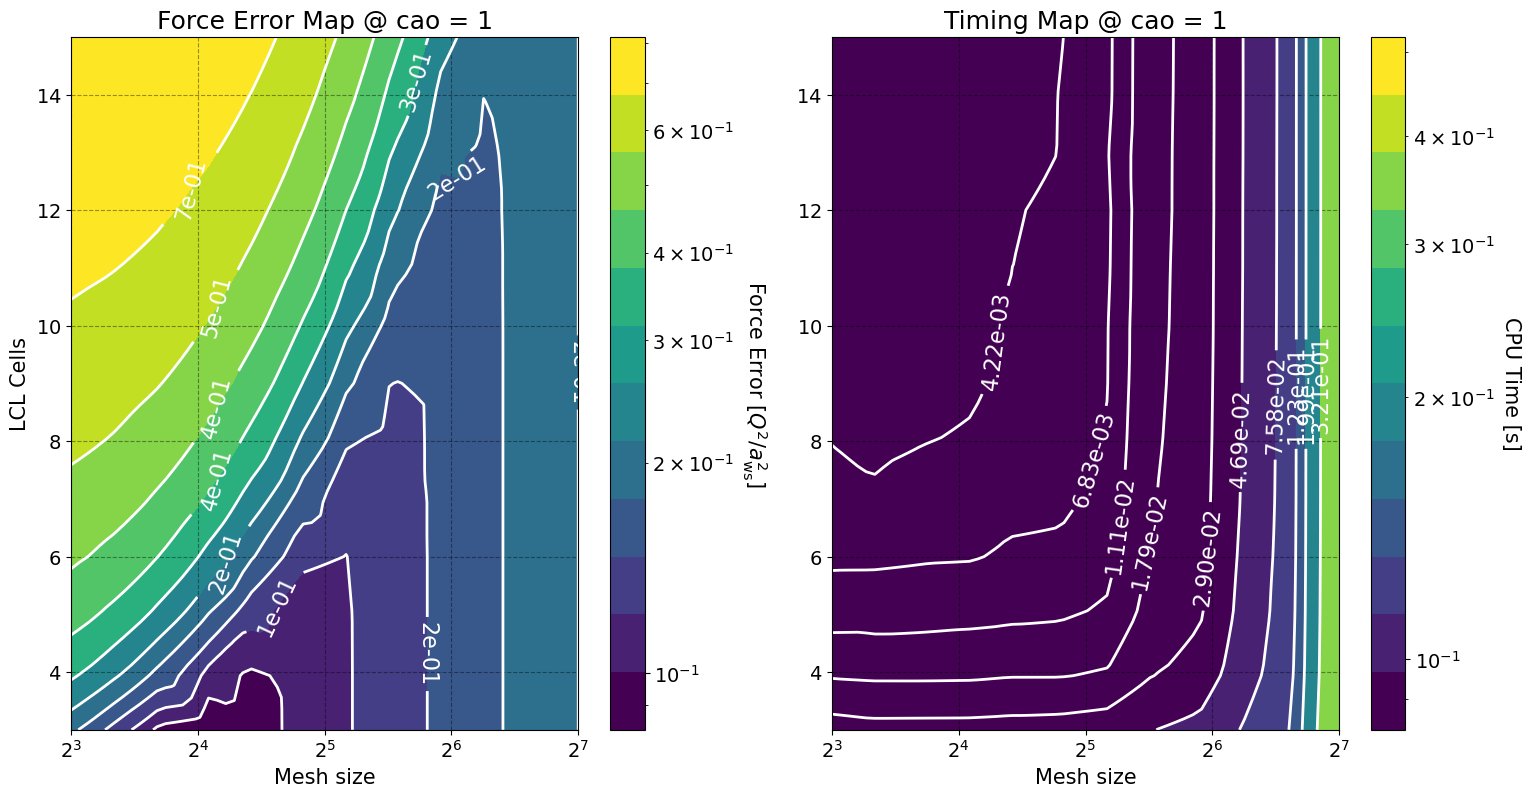

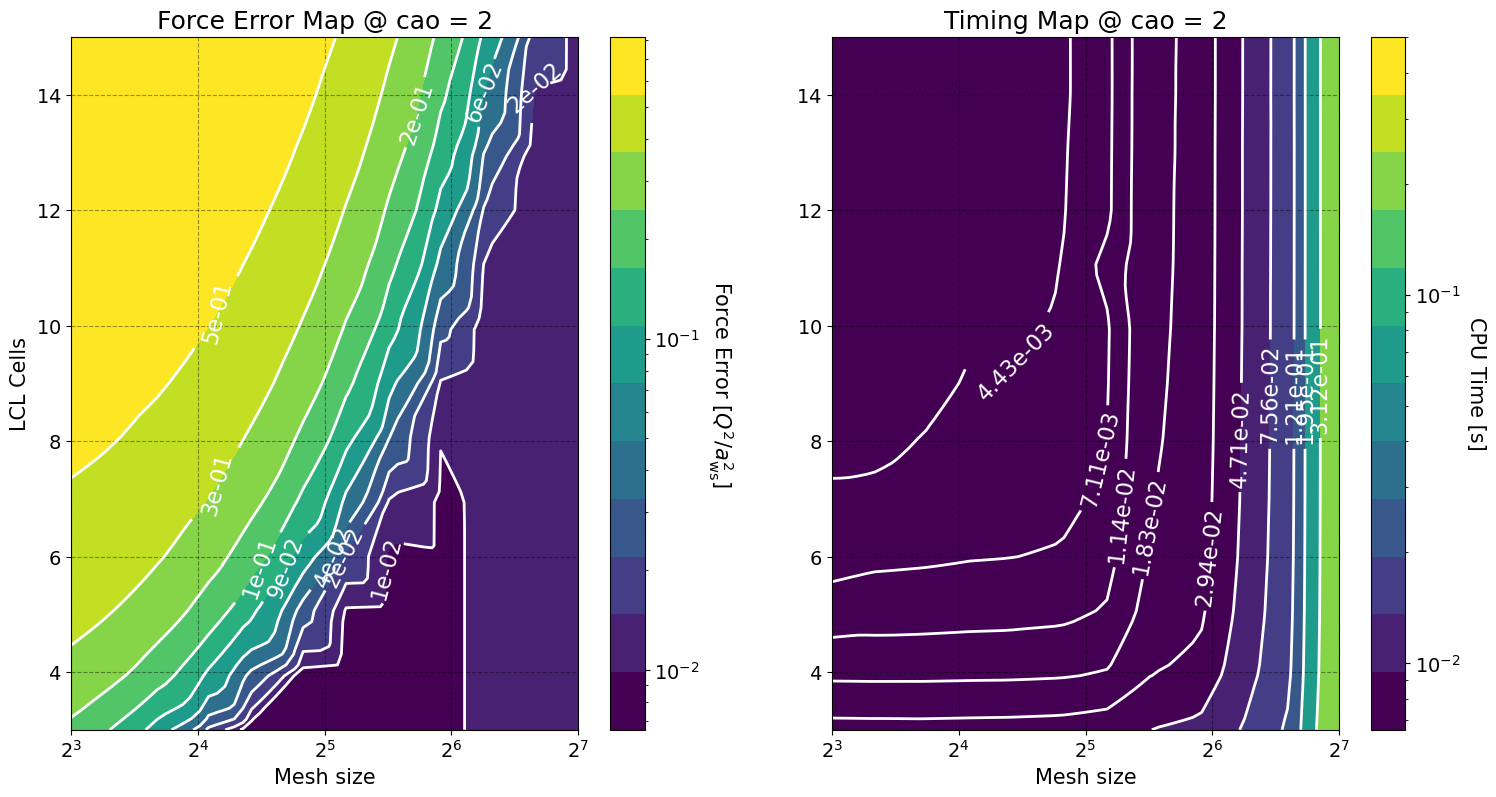

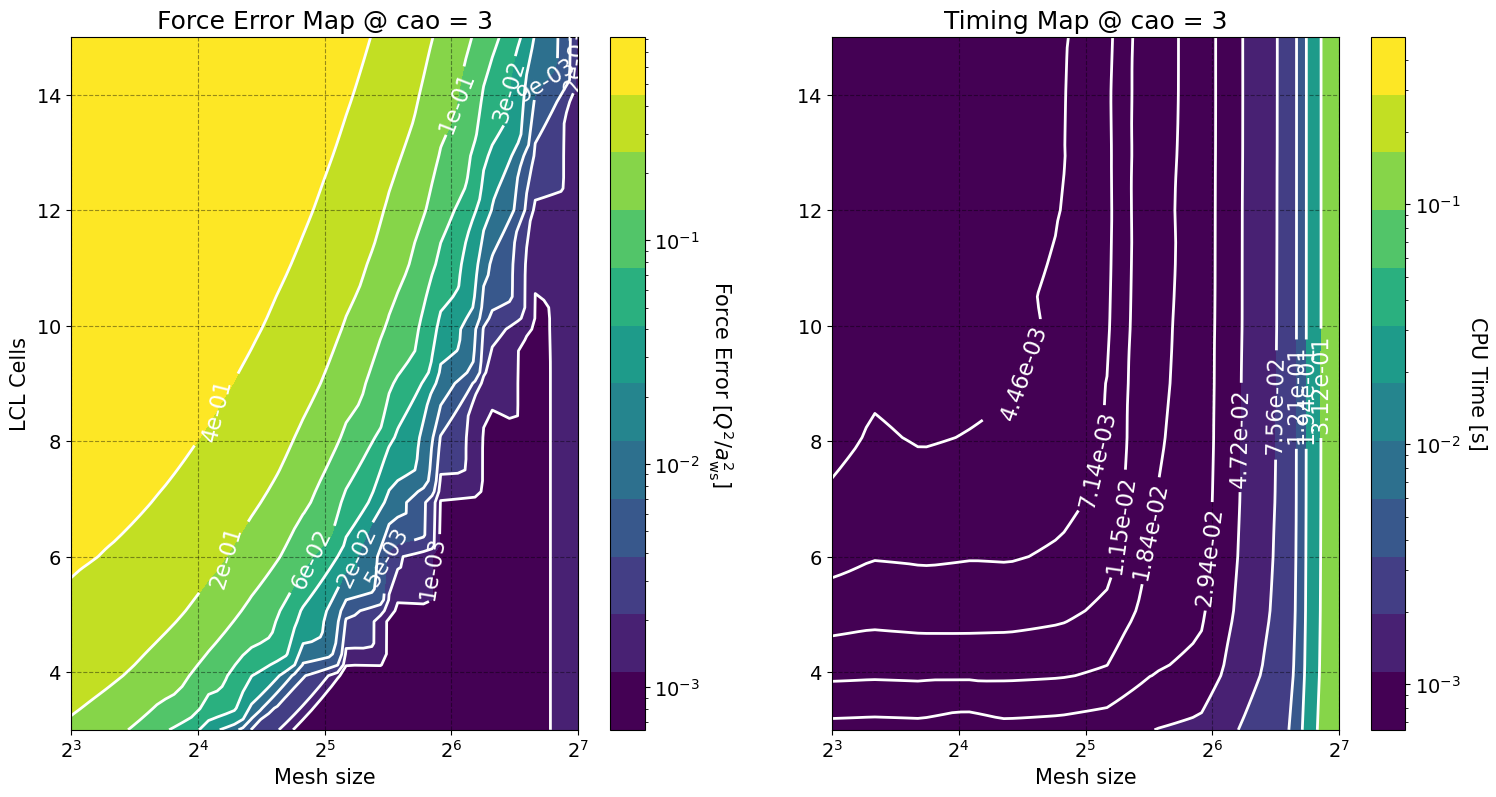

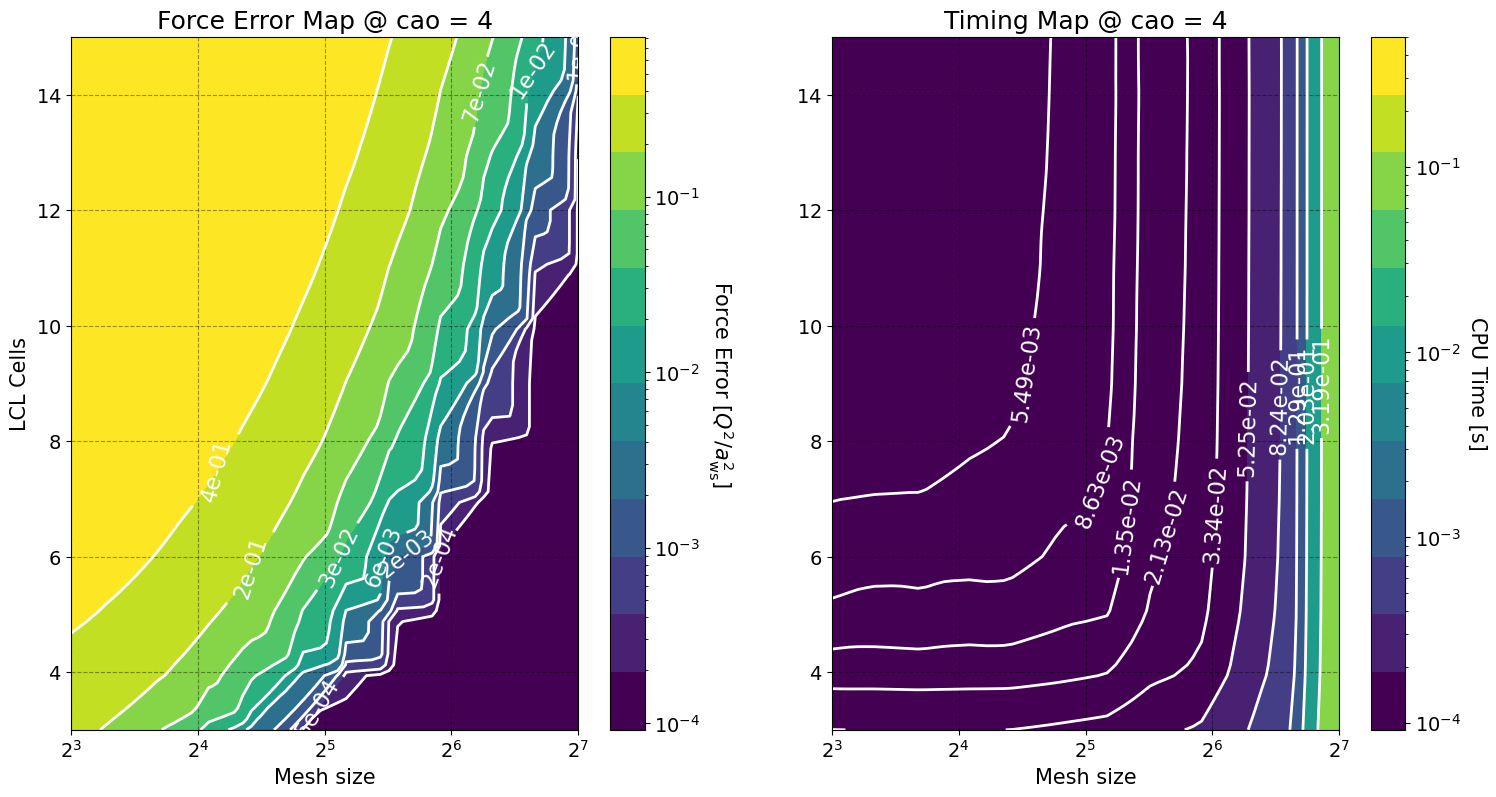

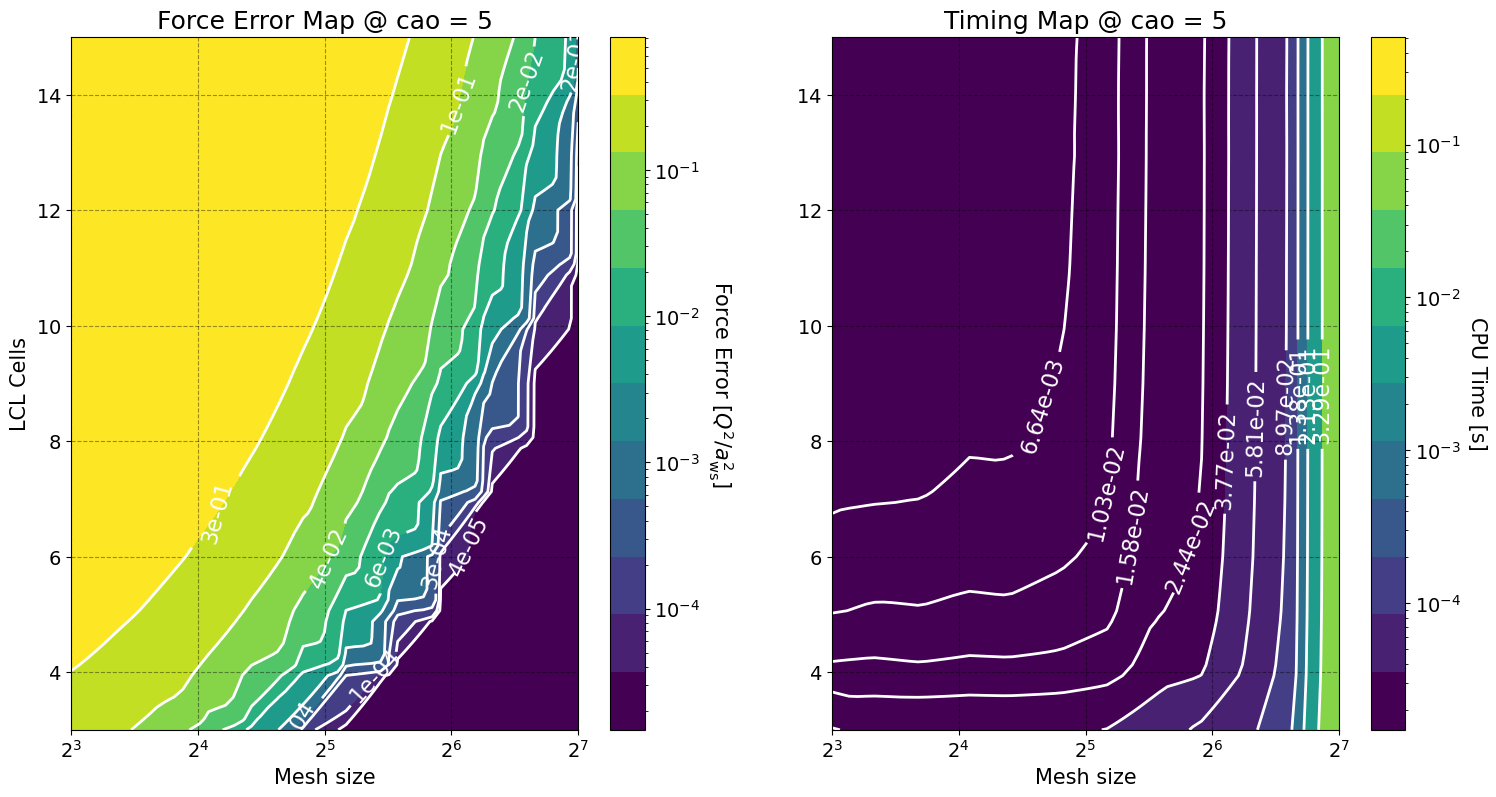

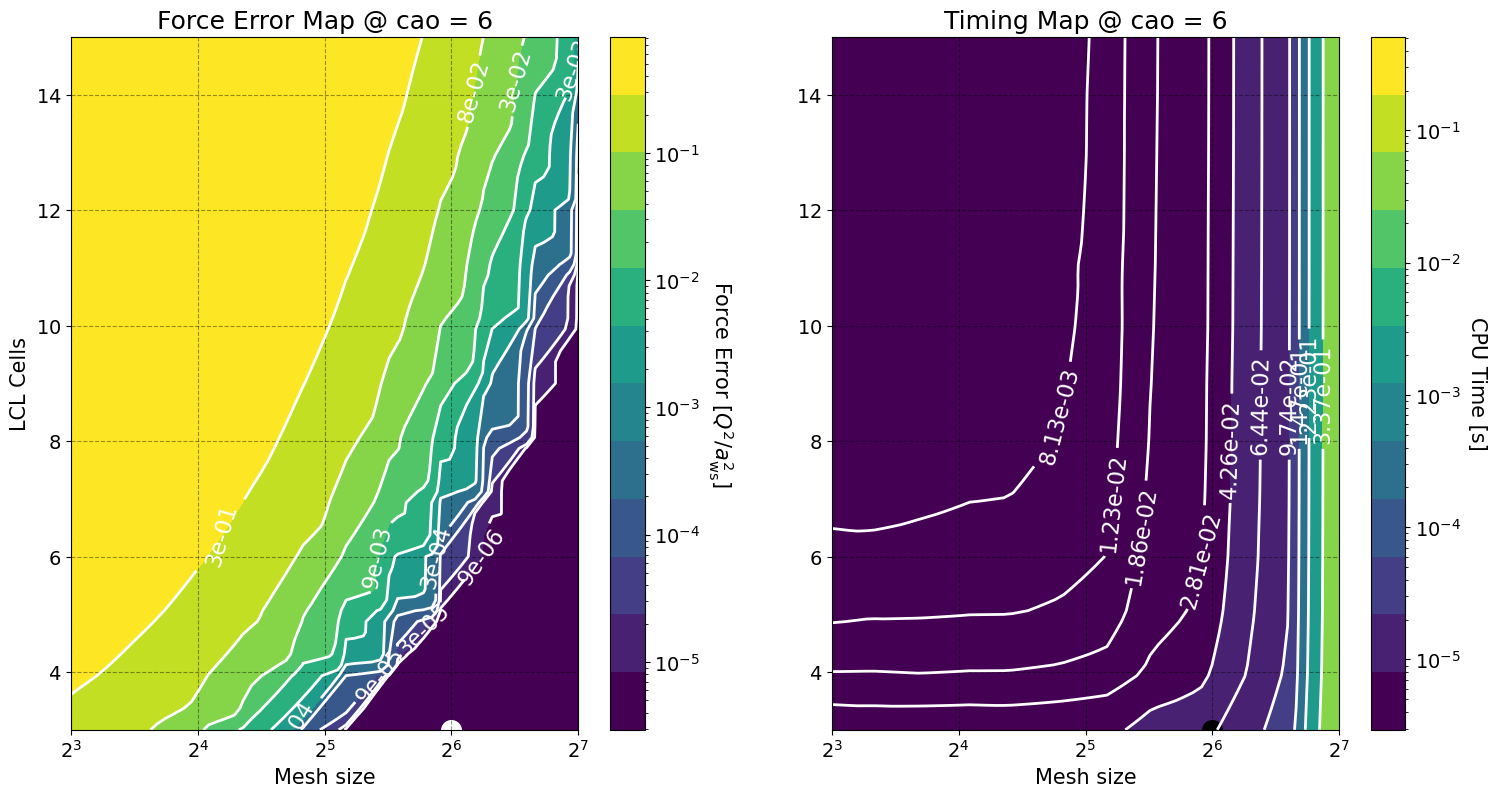

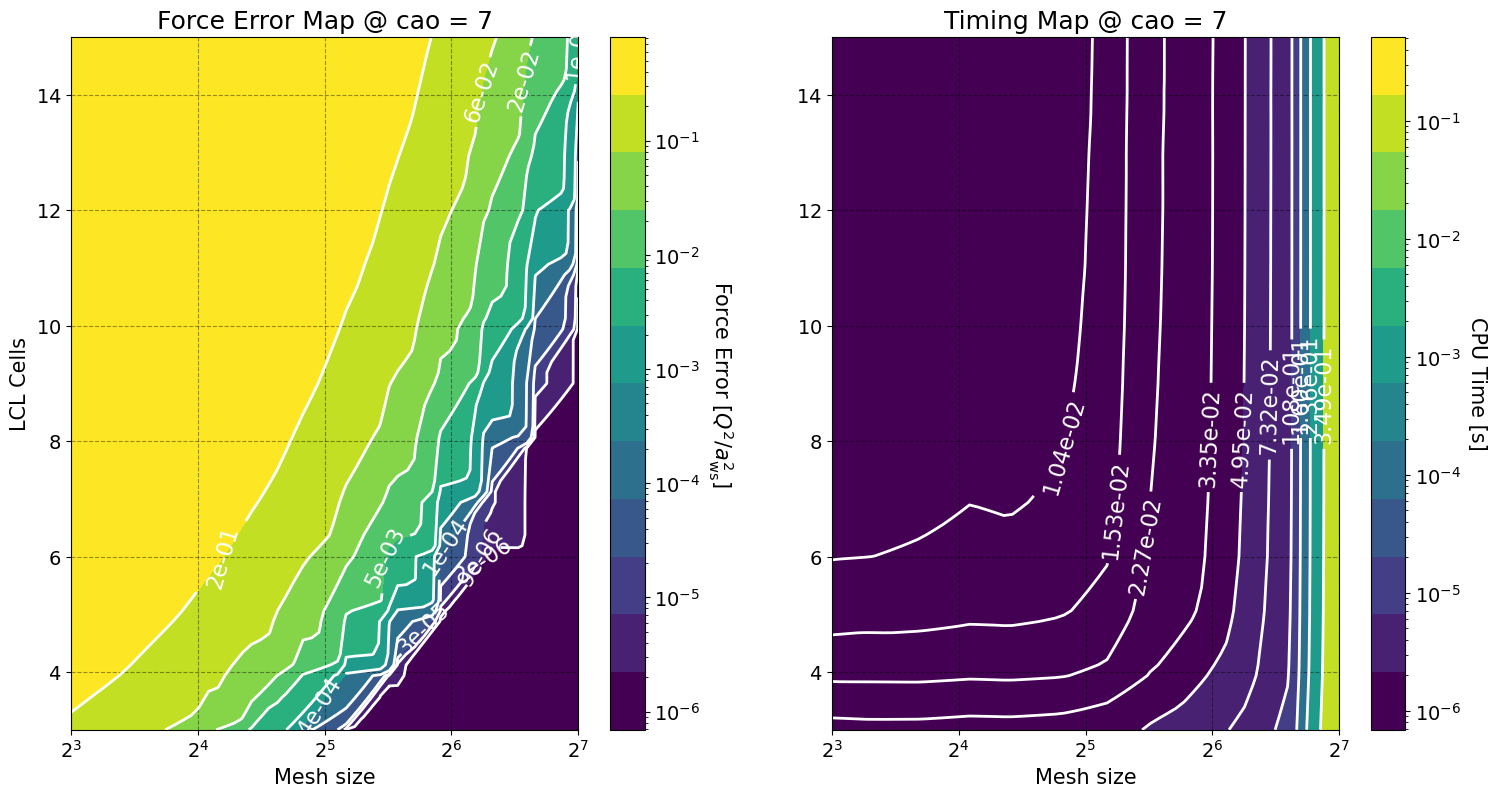

In [2]:
pre = PreProcess(input_file_name)
pre.setup(read_yaml=True)
pre.run(loops = 20, timing = True,
    pppm_estimate=True,
    timing_study = True)

In [ ]:
sim = Simulation(input_file_name)
sim.setup(read_yaml=True)
sim.run()

In [ ]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True)

In [ ]:
# Equilibration check
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters, phase = "equilibration")
therm.temp_energy_plot(postproc, )

In [ ]:
# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters)
therm.temp_energy_plot(postproc)

In [ ]:
# Radial Distribution Function 
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()
# Grab HNC data for comparison
# hnc_r, hnc_gee, hnc_gei, hnc_gii = np.loadtxt('hnc_gall.out', unpack=True)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
# ax.plot(hnc_r , hnc_gee, label = 'hnc e-e RDF')
# ax.plot(hnc_r , hnc_gei, label = 'hnc e-p RDF')
# ax.plot(hnc_r , hnc_gii, label = 'hnc p-p RDF')
rdf.plot(scaling = postproc.species[0].a_ws, 
                  y = [('e-e RDF', "Mean"),
                       ('e-p RDF', "Mean"),
                       ('p-p RDF', "Mean")
                      ],
                  ax = ax, 
                  ls = '--')
ax.legend()
ax.set(xlim = (-0.2, 6), xlabel = r'$r/a_e$', ylabel = r"$g(r)$")

In [ ]:
from sarkas.tools.observables import ElectricCurrent
from sarkas.tools.transport import TransportCoefficients

In [ ]:
ec = ElectricCurrent()
ec.setup(postproc.parameters, no_slices = 4)
#ec.compute()
ec.parse()


In [ ]:
ec.dataframe

In [ ]:
tc = TransportCoefficients(postproc.parameters)
tc.electrical_conductivity(ec, "ElectricalConductivity")

In [ ]:
tc.conductivity_df

In [ ]:
rescaling = 1.0/ec.total_plasma_frequency
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, 
        tc.conductivity_df[("Electrical Conductivity", "Mean")] * rescaling,
       label = r'$\sigma$')

ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, tc.conductivity_df[("Electrical Conductivity", "Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau$ [fs]",ylabel = r" $\sigma/\omega_p$")